**Name- Ayush Ranjane**<br>
**Roll no- TEBD23215**<br>
**Mini project**

In [4]:
#load file
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv('../data/raw/city_day.csv')
df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [9]:
df.shape

(29531, 16)

In [10]:
df.describe()

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,24933.000000,18391.000000,25949.000000,25946.000000,25346.000000,19203.000000,27472.000000,25677.000000,25509.000000,23908.000000,21490.000000,11422.000000,24850.000000
mean,67.450578,118.127103,17.574730,28.560659,32.309123,23.483476,2.248598,14.531977,34.491430,3.280840,8.700972,3.070128,166.463581
std,64.661449,90.605110,22.785846,24.474746,31.646011,25.684275,6.962884,18.133775,21.694928,15.811136,19.969164,6.323247,140.696585
min,0.040000,0.010000,0.020000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000,0.000000,0.000000,0.000000,13.000000
25%,28.820000,56.255000,5.630000,11.750000,12.820000,8.580000,0.510000,5.670000,18.860000,0.120000,0.600000,0.140000,81.000000
50%,48.570000,95.680000,9.890000,21.690000,23.520000,15.850000,0.890000,9.160000,30.840000,1.070000,2.970000,0.980000,118.000000
75%,80.590000,149.745000,19.950000,37.620000,40.127500,30.020000,1.450000,15.220000,45.570000,3.080000,9.150000,3.350000,208.000000
max,949.990000,1000.000000,390.680000,362.210000,467.630000,352.890000,175.810000,193.860000,257.730000,455.030000,454.850000,170.370000,2049.000000


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  str    
 1   Date        29531 non-null  str    
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  str    
dtypes: float64(13), str(3)
memory usage: 3.6 MB


In [14]:
#treating values
print(df.isnull().sum())
print(df.duplicated().sum())

City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64
0


In [15]:
missing_percent = df.isnull().mean() * 100
print(missing_percent.sort_values(ascending=False))

Xylene        61.322001
PM10          37.723071
NH3           34.973418
Toluene       27.229014
Benzene       19.041008
AQI           15.851139
AQI_Bucket    15.851139
PM2.5         15.570079
NOx           14.171549
O3            13.619586
SO2           13.050692
NO2           12.139785
NO            12.129626
CO             6.972334
Date           0.000000
City           0.000000
dtype: float64


In [17]:
df = df.drop(columns=['Xylene', 'Toluene'])

In [19]:
#Handle Missing Values (Numerical)
num_cols = df.select_dtypes(include=['float64', 'int64']).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [21]:
df = df.dropna(subset=['AQI'])

OUTLIERS

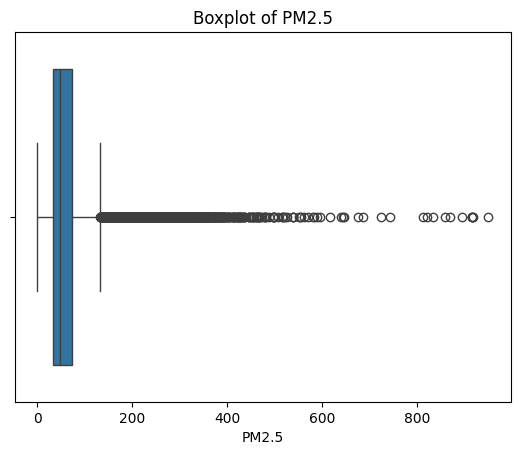

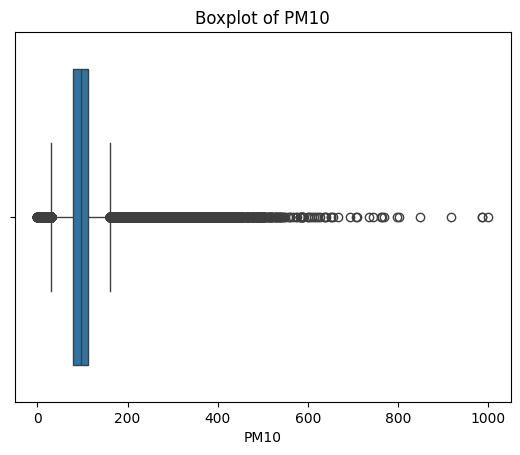

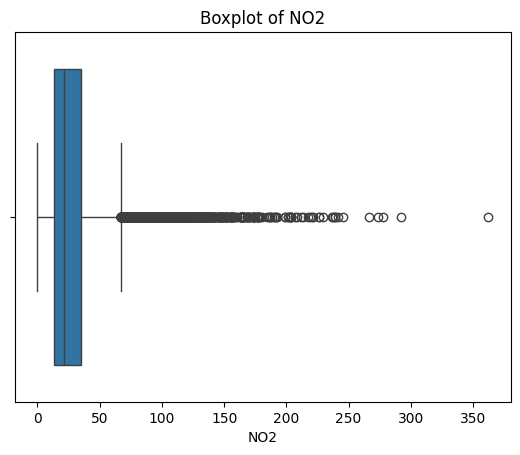

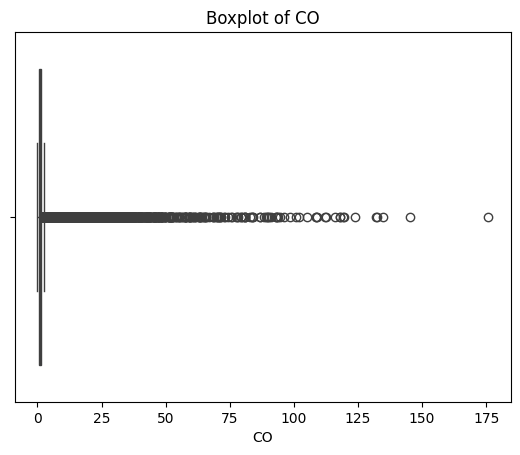

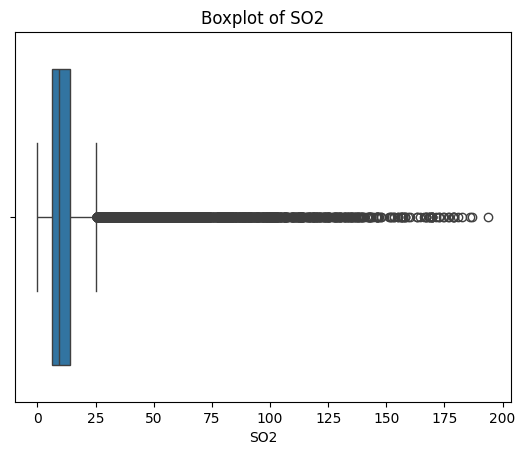

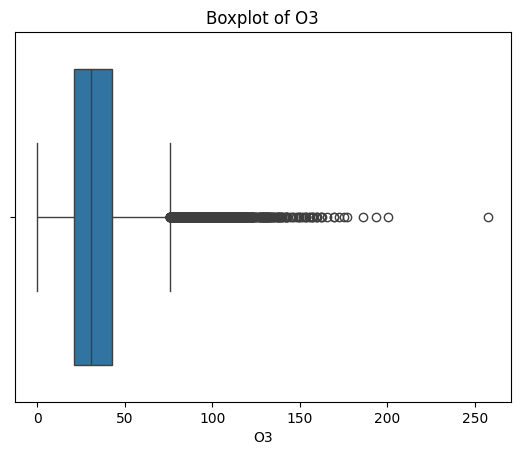

In [23]:
cols = ['PM2.5', 'PM10', 'NO2', 'CO', 'SO2', 'O3']

for col in cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [24]:
def remove_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    return df[(df[col] >= lower) & (df[col] <= upper)]

In [26]:
cols = ['PM2.5', 'PM10', 'NO2', 'CO', 'SO2', 'O3']

for col in cols:
    df = remove_outliers(df, col)

In [27]:
print(df.shape)

(17426, 14)


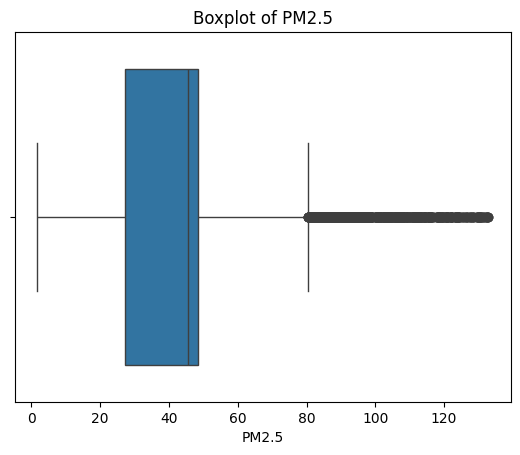

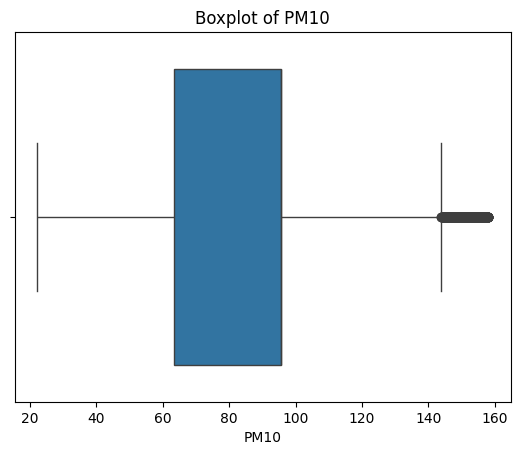

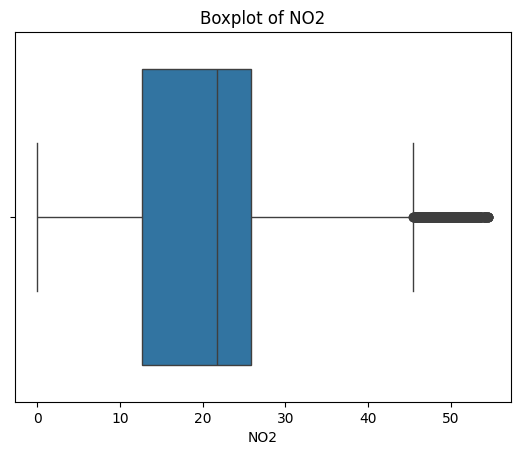

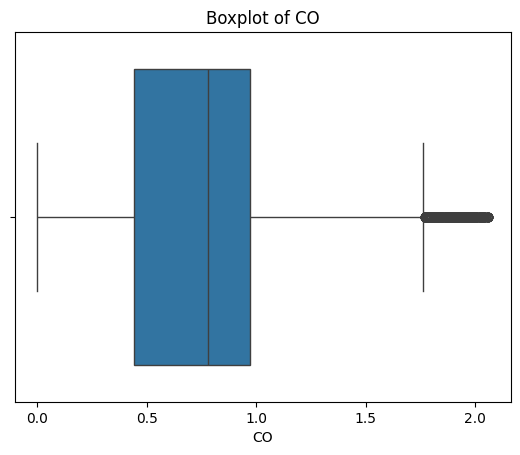

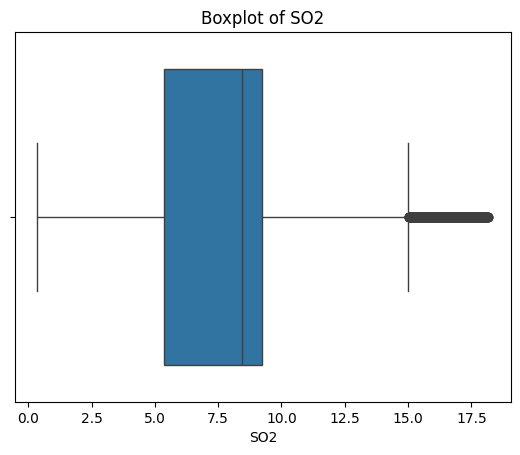

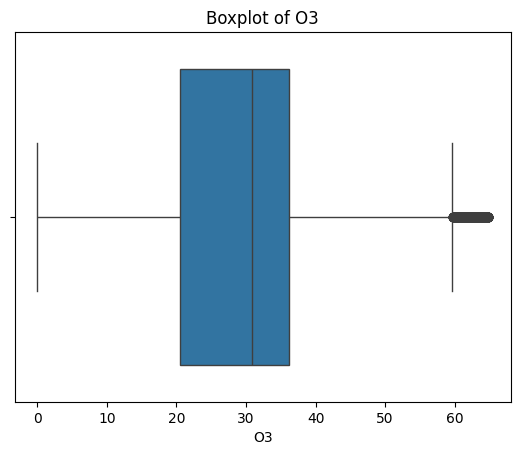

In [28]:
cols = ['PM2.5', 'PM10', 'NO2', 'CO', 'SO2', 'O3']

for col in cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [30]:
df = df.drop(columns=['AQI_Bucket'])

EDA

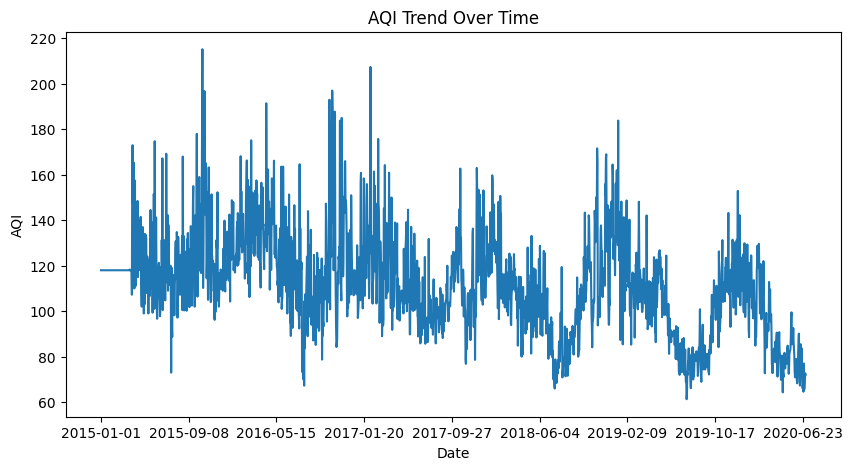

In [31]:
plt.figure(figsize=(10,5))
df.groupby('Date')['AQI'].mean().plot()
plt.title('AQI Trend Over Time')
plt.xlabel('Date')
plt.ylabel('AQI')
plt.show()

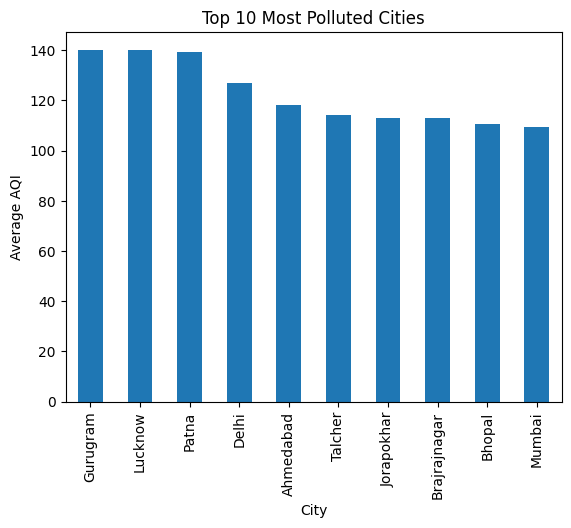

In [32]:
top_cities = df.groupby('City')['AQI'].mean().sort_values(ascending=False).head(10)

top_cities.plot(kind='bar')
plt.title('Top 10 Most Polluted Cities')
plt.ylabel('Average AQI')
plt.show()

In [37]:
print(df.dtypes)

City           str
Date           str
PM2.5      float64
PM10       float64
NO         float64
NO2        float64
NOx        float64
NH3        float64
CO         float64
SO2        float64
O3         float64
Benzene    float64
AQI        float64
dtype: object


In [40]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['City'] = le.fit_transform(df['City'])
df['Date'] = pd.to_datetime(df['Date'])

In [41]:
print(df.dtypes)

City                int64
Date       datetime64[us]
PM2.5             float64
PM10              float64
NO                float64
NO2               float64
NOx               float64
NH3               float64
CO                float64
SO2               float64
O3                float64
Benzene           float64
AQI               float64
dtype: object


In [42]:
df.columns = df.columns.str.strip().str.lower()

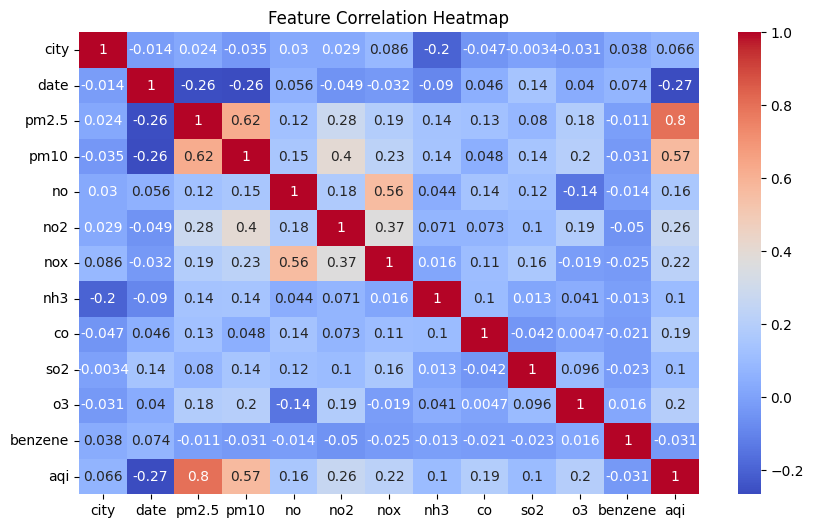

In [43]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

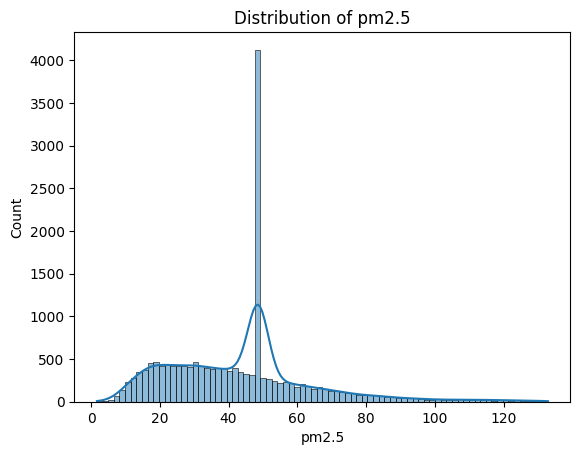

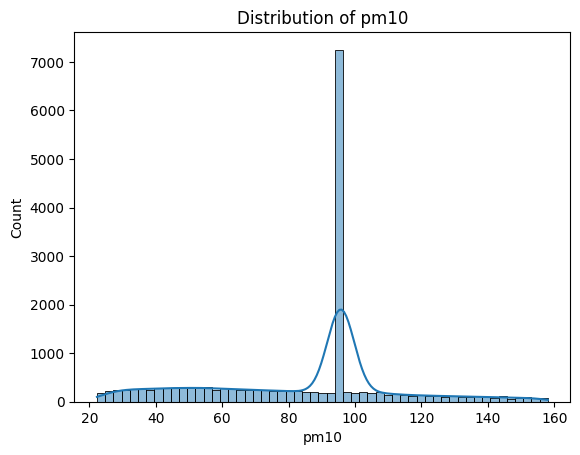

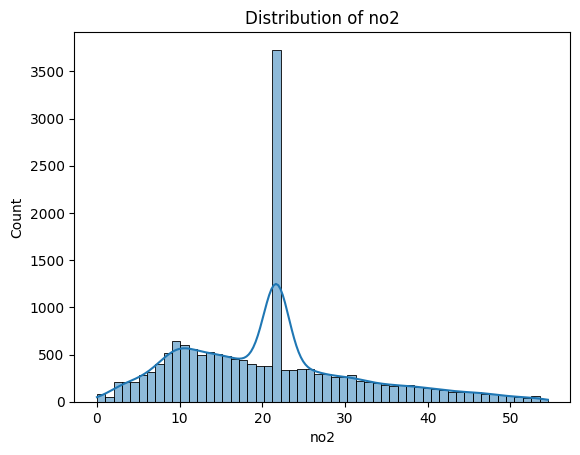

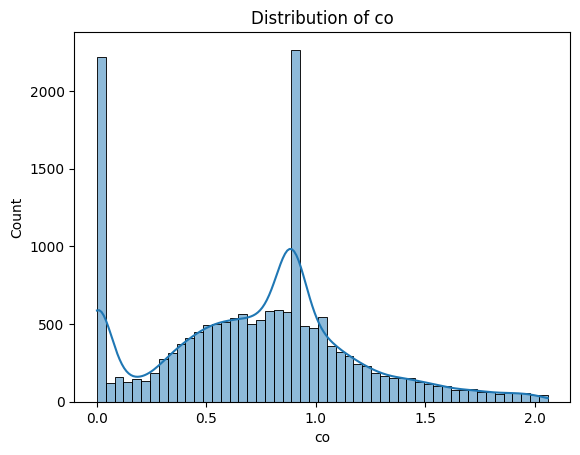

In [47]:
cols = ['pm2.5', 'pm10', 'no2', 'co']

for col in cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

ML Train

In [48]:
X = df.drop(columns=['aqi', 'date'])
y = df['aqi'] #target

In [49]:
print(X.columns)

Index(['city', 'pm2.5', 'pm10', 'no', 'no2', 'nox', 'nh3', 'co', 'so2', 'o3',
       'benzene'],
      dtype='str')


In [50]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [51]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (13940, 11)
X_test: (3486, 11)


In [52]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [53]:
df.head()

,city,date,pm2.5,pm10,no,no2,nox,nh3,co,so2,o3,benzene,aqi
9,0,2015-01-10,48.57,95.68,9.89,7.04,0.00,15.85,0.89,8.29,4.55,0.00,118.0
56,0,2015-02-26,48.57,95.68,9.89,21.69,23.52,15.85,0.89,9.16,30.84,1.07,118.0
57,0,2015-02-27,48.57,95.68,9.89,21.69,23.52,15.85,0.89,9.16,30.84,1.07,118.0
58,0,2015-02-28,48.57,95.68,9.89,21.69,23.52,15.85,0.89,9.16,30.84,1.07,118.0
64,0,2015-03-06,48.57,95.68,9.89,21.69,23.52,15.85,0.89,9.16,30.84,1.07,118.0


In [54]:
print(X_train_scaled[:5])

[[7.20000000e-01 1.57842463e-01 8.51988218e-02 5.41346305e-03
  5.41552009e-01 6.76817142e-02 1.04001360e-02 1.84466019e-01
  4.82874789e-02 3.12451782e-01 7.05727163e-03]
 [1.20000000e-01 2.21483689e-01 7.90132548e-01 2.68319473e-02
  3.12786645e-01 5.02961743e-02 2.91033779e-02 4.12621359e-01
  2.55474453e-01 1.38867459e-01 3.09992305e-03]
 [8.00000000e-01 3.55794942e-01 5.40648012e-01 2.57074115e-02
  3.97725188e-01 2.74062827e-01 4.48877805e-02 0.00000000e+00
  4.94104436e-01 4.75543898e-01 0.00000000e+00]
 [4.00000000e-01 3.14691726e-01 5.31222386e-01 1.14022700e-02
  3.39020363e-01 3.12640335e-02 8.33711177e-02 3.64077670e-01
  7.56878158e-01 9.88736306e-01 3.29779048e-03]
 [3.20000000e-01 2.69233708e-01 5.40648012e-01 1.46189654e-02
  2.52430747e-01 4.12291769e-02 1.04284743e-02 4.90291262e-01
  2.63335205e-01 4.07035951e-01 3.29779048e-04]]


In [55]:
# Lr
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [56]:
#Random Forest
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [57]:
# XGBoost
from xgboost import XGBRegressor

xgb = XGBRegressor(random_state=42)
xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

Evaluation (BEFORE TUNING)

In [60]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def evaluate(model, X, y, name):
    pred = model.predict(X)
    
    rmse = np.sqrt(mean_squared_error(y, pred))
    mae = mean_absolute_error(y, pred)
    r2 = r2_score(y, pred)
    
    print(f"{name} Performance:")
    print("RMSE:", rmse)
    print("MAE:", mae)
    print("R2:", r2)
    print("----------------------")
    
    return rmse, mae, r2

In [61]:
lr_metrics = evaluate(lr, X_test_scaled, y_test, "Linear Regression")
rf_metrics = evaluate(rf, X_test, y_test, "Random Forest")
xgb_metrics = evaluate(xgb, X_test, y_test, "XGBoost")

Linear Regression Performance:
RMSE: 25.856465088159865
MAE: 16.641405664189836
R2: 0.6684321527066781
----------------------
Random Forest Performance:
RMSE: 23.075430357632232
MAE: 12.31158740368915
R2: 0.7359210852933986
----------------------
XGBoost Performance:
RMSE: 23.954901993748877
MAE: 12.839591334348976
R2: 0.7154078579565016
----------------------


Hyperparameter Tuning

In [69]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

rf_params = {
    'n_estimators': [200, 300],
    'max_depth': [20, 30],
    'min_samples_split': [2, 5, 10]
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    rf_params,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_

In [70]:
print(rf_grid.best_params_)

{'max_depth': 20, 'min_samples_split': 10, 'n_estimators': 300}


In [ ]:
# Xgboost tunning
from xgboost import XGBRegressor

xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6],
    'learning_rate': [0.05, 0.1]
}

xgb_grid = GridSearchCV(
    XGBRegressor(random_state=42),
    xgb_params,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)

best_xgb = xgb_grid.best_estimator_

In [68]:
print(xgb_grid.best_params_)

{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}


In [65]:
#Lr tunning
lr_tuned = LinearRegression()
lr_tuned.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


After tunning results

In [71]:
lr_after = evaluate(lr_tuned, X_test_scaled, y_test, "Linear Regression Tuned")
rf_after = evaluate(best_rf, X_test, y_test, "Random Forest Tuned")
xgb_after = evaluate(best_xgb, X_test, y_test, "XGBoost Tuned")

Linear Regression Tuned Performance:
RMSE: 25.856465088159865
MAE: 16.641405664189836
R2: 0.6684321527066781
----------------------
Random Forest Tuned Performance:
RMSE: 22.955103673103658
MAE: 12.246686067552096
R2: 0.7386679803737353
----------------------
XGBoost Tuned Performance:
RMSE: 23.32669392326621
MAE: 12.855738316468651
R2: 0.7301387737240457
----------------------


In [72]:
results_after = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'RMSE': [lr_after[0], rf_after[0], xgb_after[0]],
    'MAE': [lr_after[1], rf_after[1], xgb_after[1]],
    'R2': [lr_after[2], rf_after[2], xgb_after[2]]
})

print(results_after)

               Model       RMSE        MAE        R2
0  Linear Regression  25.856465  16.641406  0.668432
1      Random Forest  22.955104  12.246686  0.738668
2            XGBoost  23.326694  12.855738  0.730139


In [76]:
import pickle

# Save models
pickle.dump(best_rf, open('../Models/rf_model.pkl', 'wb'))
pickle.dump(best_xgb, open('../Models/xgb_model.pkl', 'wb'))
pickle.dump(lr_tuned, open('../Models/lr_model.pkl', 'wb'))

# Save scaler
pickle.dump(scaler, open('../Models/scaler.pkl', 'wb'))